In [1]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from tqdm import tqdm, trange

from datasets import load_dataset
import pandas as pd
import functools
import sys
from pathlib import Path
from typing import Callable

# import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import eindex
# from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer
import os
import json
import matplotlib.pyplot as plt
import math
import seaborn as sns

/home/kokil/shaz/interp-toxicity/interp-toxicity2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer  = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=True      # optional
).to(device)
model.eval()
model.load_state_dict(torch.load('bert_classifier_vanilla/model_epoch_2_acc_0.9236.pt', map_location=device))

2025-06-04 09:28:13.839189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-04 09:28:13.853309: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749029293.870998 1265629 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749029293.876393 1265629 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749029293.890437 1265629 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

<All keys matched successfully>

## Patching

In [3]:
import torch
from contextlib import contextmanager

def make_zero_head_hook(head_idx: int, num_heads: int, head_dim: int):
    def hook(module, input, output):
        # In BERT's self-attention, the output is a tuple of (context_layer, attention_probs)
        context_layer, attention_probs = output

        # Reshape attention probabilities to separate heads
        # attention_probs shape: (batch_size, num_heads, seq_len, seq_len)
        # Zero out the attention weights for the specified head
        attention_probs[:, head_idx, :, :] = 0.0
        
        # Get the value projections from the input
        value_layer = input[0]  # This is the value projection
        b, s, h = value_layer.shape
        value_layer = value_layer.view(b, s, num_heads, head_dim)
        
        # Transpose value_layer to match attention_probs dimensions
        # From (batch_size, seq_len, num_heads, head_dim) to (batch_size, num_heads, seq_len, head_dim)
        value_layer = value_layer.transpose(1, 2)
        
        # Compute new context layer with zeroed attention weights
        # attention_probs: (batch_size, num_heads, seq_len, seq_len)
        # value_layer: (batch_size, num_heads, seq_len, head_dim)
        context_layer = torch.matmul(attention_probs, value_layer)
        
        # Transpose back to original shape
        context_layer = context_layer.transpose(1, 2)
        context_layer = context_layer.reshape(b, s, h)
        
        return (context_layer, attention_probs)

    return hook

@contextmanager
def zero_head(model, layer_idx: int, head_idx: int):
    """
    Context-manager that installs the hook, yields, then removes it.
    """
    sa = model.bert.encoder.layer[layer_idx].attention.self
    hd = model.config.hidden_size // model.config.num_attention_heads
    handle = sa.register_forward_hook(
        make_zero_head_hook(head_idx, model.config.num_attention_heads, hd)
    )
    try:
        yield
    finally:
        handle.remove()


In [56]:
criterion = nn.CrossEntropyLoss()

In [57]:
def get_ablation_scores_plain(
    classifier: nn.Module,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    labels: torch.Tensor,
):
    n_layers     = classifier.config.num_hidden_layers
    n_heads      = classifier.config.num_attention_heads
    d_head       = classifier.config.hidden_size // n_heads
    device       = input_ids.device
    scores       = torch.zeros(n_layers, n_heads, device=device)
    predictions  = {}

    # baseline
    with torch.no_grad():
        base_logits = classifier(input_ids, attention_mask)
        base_preds = torch.argmax(base_logits.logits, dim=-1)
        base_loss   = criterion(base_logits.logits, labels)

    # per-head ablation
    for L in trange(n_layers):
        for H in range(n_heads):
            with zero_head(classifier, L, H):
                with torch.no_grad():
                    logits = classifier(input_ids)
                    loss   = criterion(logits.logits, labels)
                    preds = torch.argmax(logits.logits, dim=-1)
            scores[L, H] = loss - base_loss        # Δ-loss
            predictions[(L, H)] = preds.detach().cpu()
    return scores, base_preds, predictions


In [76]:
df = pd.read_csv('jigsaw/test.csv')

In [87]:
Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))

Dataset({
    features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
    num_rows: 2000
})

In [88]:
# dataset = load_dataset("csv", data_files={"jigsaw/test.csv"})
dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["comment_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("toxic", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 2000/2000 [00:00<00:00, 7977.98 examples/s]


In [89]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 16
val_dataloader = DataLoader(JigsawDataset(dataset), batch_size=batch_size, shuffle=False)

In [91]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores_plain(model, input_ids, attention_mask, labels)
    ablation_scores += tmp_ablation_scores
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    if i == 16:
        break

# ablation_scores /= len(val_dataloader)
# torch.save(ablation_scores, "bert_ablation_scores_jigsaw_perturbed.pth")

patching


 13%|█▎        | 16/125 [03:14<22:02, 12.13s/it]


## Testing

In [ ]:
success = 0
total = 0
for i in range(len(input_df)):
    out = model(tokenizer(input_df.perturbed_text[i], return_tensors='pt')['input_ids'].to(device))
    pred = out.logits.argmax(dim=-1)
    if pred == input_df.ground_truth_output[i]:
        success += 1
    total += 1
    print(100 * success / total)

## Analysis

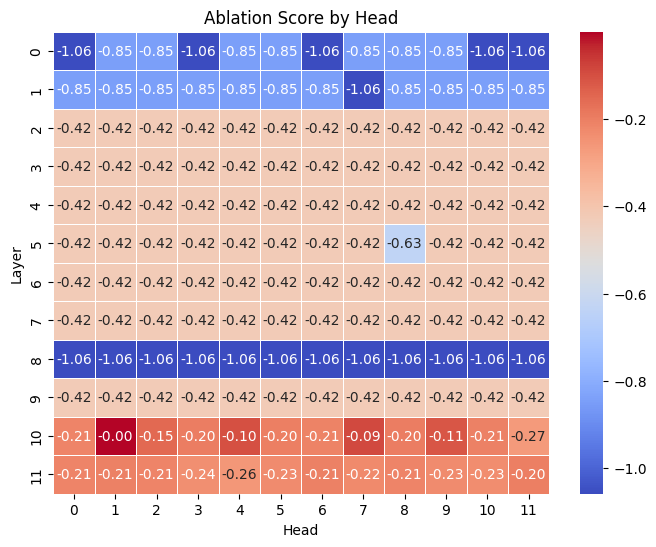

In [92]:
tensor_np = ablation_scores.cpu().detach().numpy()
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# Show the plot
plt.show()

In [93]:
sum(base_preds)

5

In [94]:
acc_scores = np.zeros((12,12))
for i in range(12):
    for j in range(12):
        acc_scores[i][j] = np.mean(np.array(base_preds) == np.array(ablated_preds[i][j]))

In [95]:
acc_scores

array([[0.98161765, 0.98529412, 0.98529412, 0.98161765, 0.98529412,
        0.98529412, 0.98161765, 0.98529412, 0.98529412, 0.98529412,
        0.98161765, 0.98161765],
       [0.98529412, 0.98529412, 0.98529412, 0.98529412, 0.98529412,
        0.98529412, 0.98529412, 0.98161765, 0.98529412, 0.98529412,
        0.98529412, 0.98529412],
       [0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706],
       [0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706],
       [0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706],
       [0.99264706, 0.99264706, 0.99264706, 0.99264706, 0.99264706,
        0.99264706, 0.99264706, 0.99264706, 0.98897059, 0.99264706,
        0.99264706,

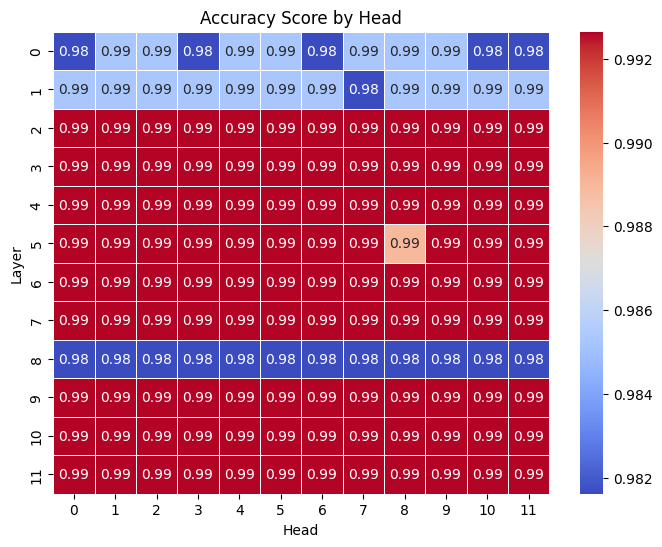

In [96]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(acc_scores, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'{attack_name}/bert_jigsaw_perturbed_accuracy_scores_by_head.png')
# Show the plot
plt.show()